# Air Quality Prediction Using Linear Regression in Machine Learning

**ML Type:** Regression (Linear Regression)

## Program

### Import the required libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

### Upload Dataset File

In [2]:
# Only needed in Google Colab (skip if 'AirQualityUCI.csv' is in the same folder)
# from google.colab import files
# uploaded = files.upload()

### Load the Dataset

In [3]:
df = pd.read_csv("AirQualityUCI.csv")
print("Air Quality Dataset Shape:", df.shape)
df.head()

Air Quality Dataset Shape: (9357, 15)


,Date,Time,CO_GT,PT08_S1_CO,NMHC_GT,C6H6_GT,PT08_S2_NMHC,NOx_GT,PT08_S3_NOx,NO2_GT,PT08_S4_NO2,PT08_S5_O3,T,RH,AH
0,10-03-2004,18:00:00,2.6,1360,150,11.9,1046,166,1056,113,1692,1268,13.6,48.9,0.7578
1,10-03-2004,19:00:00,2.0,1292,112,9.4,955,103,1174,92,1559,972,13.3,47.7,0.7255
2,10-03-2004,20:00:00,2.2,1402,88,9.0,939,131,1140,114,1555,1074,11.9,54.0,0.7502
3,10-03-2004,21:00:00,2.2,1376,80,9.2,948,172,1092,122,1584,1203,11.0,60.0,0.7867
4,10-03-2004,22:00:00,1.6,1272,51,6.5,836,131,1205,116,1490,1110,11.2,59.6,0.7888


### Check Dataset Information

In [4]:
print(df.columns)
print("Missing Values (marked as -200):")
print((df == -200).sum())

Index(['Date', 'Time', 'CO_GT', 'PT08_S1_CO', 'NMHC_GT', 'C6H6_GT',
       'PT08_S2_NMHC', 'NOx_GT', 'PT08_S3_NOx', 'NO2_GT', 'PT08_S4_NO2',
       'PT08_S5_O3', 'T', 'RH', 'AH'],
      dtype='str')
Missing Values (marked as -200):
Date               0
Time               0
CO_GT           1683
PT08_S1_CO       366
NMHC_GT         8443
C6H6_GT          366
PT08_S2_NMHC     366
NOx_GT          1639
PT08_S3_NOx      366
NO2_GT          1642
PT08_S4_NO2      366
PT08_S5_O3       366
T                366
RH               366
AH               366
dtype: int64


### Replace Missing Value Markers

In [5]:
df = df.replace(-200, np.nan)
print("Missing Values After Replacement:")
print(df.isnull().sum())

Missing Values After Replacement:
Date               0
Time               0
CO_GT           1683
PT08_S1_CO       366
NMHC_GT         8443
C6H6_GT          366
PT08_S2_NMHC     366
NOx_GT          1639
PT08_S3_NOx      366
NO2_GT          1642
PT08_S4_NO2      366
PT08_S5_O3       366
T                366
RH               366
AH               366
dtype: int64


### Remove Unnecessary Columns

In [6]:
df["Hour"] = df["Time"].str[:2].astype(int)
df = df.drop(["Date", "Time", "NMHC_GT"], axis=1)
df = df.dropna()
print("Dataset Shape After Cleaning:", df.shape)
df.head()

Dataset Shape After Cleaning: (6941, 13)


,CO_GT,PT08_S1_CO,C6H6_GT,PT08_S2_NMHC,NOx_GT,PT08_S3_NOx,NO2_GT,PT08_S4_NO2,PT08_S5_O3,T,RH,AH,Hour
0,2.6,1360.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578,18
1,2.0,1292.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255,19
2,2.2,1402.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502,20
3,2.2,1376.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867,21
4,1.6,1272.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888,22


### Statistical Summary of the Dataset

In [7]:
df[["CO_GT", "C6H6_GT", "NOx_GT", "NO2_GT", "T", "RH"]].describe().round(2)

,CO_GT,C6H6_GT,NOx_GT,NO2_GT,T,RH
count,6941.00,6941.00,6941.00,6941.00,6941.00,6941.00
mean,2.18,10.55,250.67,113.87,17.76,48.88
std,1.44,7.47,208.61,47.48,8.84,17.43
min,0.10,0.20,2.00,2.00,-1.90,9.20
25%,1.10,4.90,103.00,79.00,11.20,35.30
50%,1.90,8.80,186.00,110.00,16.80,49.20
75%,2.90,14.60,335.00,142.00,23.70,62.20
max,11.90,63.70,1479.00,333.00,44.60,88.70


### Check Correlation with CO Concentration

In [8]:
print(df.corr()["CO_GT"].sort_values(ascending=False).round(3))

CO_GT           1.000
C6H6_GT         0.930
PT08_S2_NMHC    0.914
PT08_S1_CO      0.877
PT08_S5_O3      0.853
NOx_GT          0.786
NO2_GT          0.674
PT08_S4_NO2     0.631
Hour            0.335
RH              0.065
AH              0.059
T               0.018
PT08_S3_NOx    -0.701
Name: CO_GT, dtype: float64


### Visualize Dataset

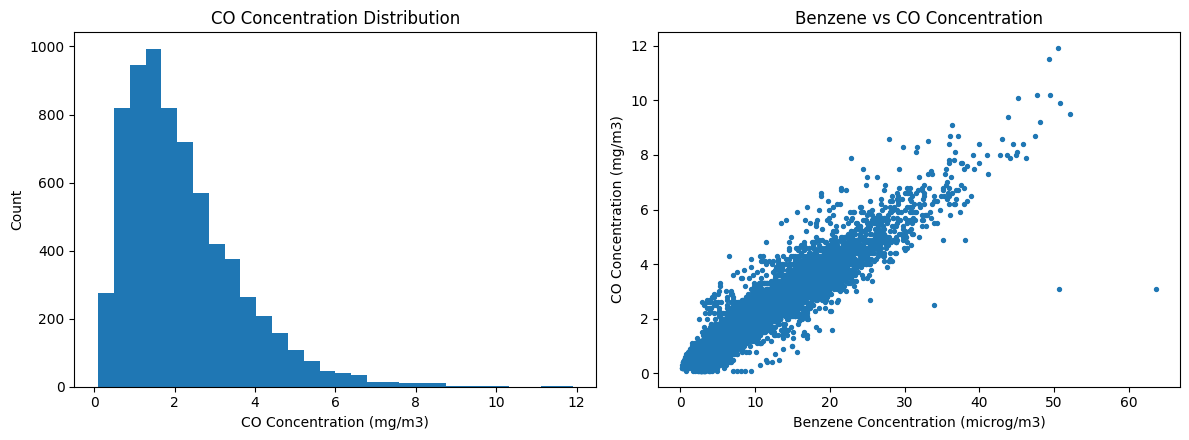

In [9]:
plt.figure(figsize=(12, 4.5))

plt.subplot(1, 2, 1)
plt.hist(df["CO_GT"], bins=30)
plt.xlabel("CO Concentration (mg/m3)")
plt.ylabel("Count")
plt.title("CO Concentration Distribution")

plt.subplot(1, 2, 2)
plt.scatter(df["C6H6_GT"], df["CO_GT"], s=8)
plt.xlabel("Benzene Concentration (microg/m3)")
plt.ylabel("CO Concentration (mg/m3)")
plt.title("Benzene vs CO Concentration")

plt.tight_layout()
plt.show()

### Split Input and Output

In [10]:
X = df.drop("CO_GT", axis=1)
y = df["CO_GT"]

### Train-Test Split

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (5552, 12)
Testing Data: (1389, 12)


### Train Linear Regression Model

In [12]:
model = LinearRegression()
model.fit(
    X_train,
    y_train
)
print("Model Training Completed!")

Model Training Completed!


### Make Predictions

In [13]:
y_pred = model.predict(X_test)
print(y_pred[:10].round(2))

[2.99 1.27 3.03 1.76 2.03 1.22 5.24 1.59 0.72 0.96]


### Calculate Evaluation Metrics

In [14]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error (MAE):", round(mae, 4))
print("Mean Squared Error (MSE):", round(mse, 4))
print("Root Mean Squared Error (RMSE):", round(rmse, 4))
print("R2 Score:", round(r2, 4))
print("Model Accuracy (R2 x 100):", round(r2 * 100, 2), "%")

Mean Absolute Error (MAE): 0.2592
Mean Squared Error (MSE): 0.1574
Root Mean Squared Error (RMSE): 0.3968
R2 Score: 0.9166
Model Accuracy (R2 x 100): 91.66 %


### Actual vs Predicted CO Concentration

In [15]:
comparison = pd.DataFrame({
    "Actual CO": y_test.values,
    "Predicted CO": y_pred.round(2)
})
comparison.head()

,Actual CO,Predicted CO
0,2.8,2.99
1,1.1,1.27
2,3.7,3.03
3,1.7,1.76
4,1.9,2.03


### Actual vs Predicted Graph

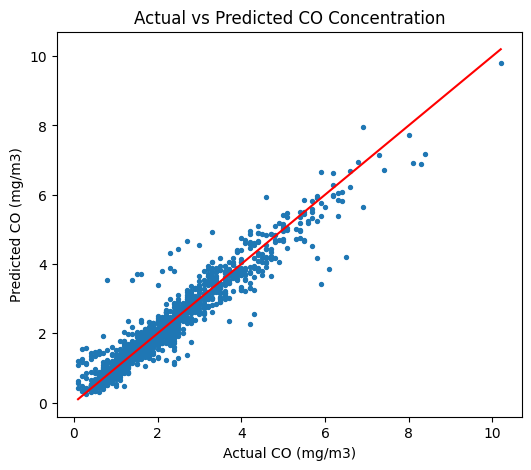

In [16]:
plt.figure(figsize=(6, 5))
plt.scatter(y_test, y_pred, s=8)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], color="red")
plt.xlabel("Actual CO (mg/m3)")
plt.ylabel("Predicted CO (mg/m3)")
plt.title("Actual vs Predicted CO Concentration")
plt.show()

### Feature Coefficients

In [17]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_.round(6)
})
coefficients

,Feature,Coefficient
0,PT08_S1_CO,0.001150
1,C6H6_GT,0.124279
2,PT08_S2_NMHC,-0.000646
3,NOx_GT,0.001576
4,PT08_S3_NOx,0.000197
5,NO2_GT,0.001804
6,PT08_S4_NO2,0.000698
7,PT08_S5_O3,-0.000200
8,T,-0.020067
9,RH,-0.003396


### Predict Air Quality for New Sensor Readings

In [18]:
def predict_air_quality(pt08_s1_co, c6h6, pt08_s2_nmhc, nox, pt08_s3_nox,
                        no2, pt08_s4_no2, pt08_s5_o3, temperature,
                        humidity, absolute_humidity, hour):
    input_data = pd.DataFrame([{
        "PT08_S1_CO": pt08_s1_co,
        "C6H6_GT": c6h6,
        "PT08_S2_NMHC": pt08_s2_nmhc,
        "NOx_GT": nox,
        "PT08_S3_NOx": pt08_s3_nox,
        "NO2_GT": no2,
        "PT08_S4_NO2": pt08_s4_no2,
        "PT08_S5_O3": pt08_s5_o3,
        "T": temperature,
        "RH": humidity,
        "AH": absolute_humidity,
        "Hour": hour
    }])
    input_data = input_data[X.columns]
    co = model.predict(input_data)
    return round(co[0], 2)

result = predict_air_quality(
    pt08_s1_co=1360,
    c6h6=11.9,
    pt08_s2_nmhc=1046,
    nox=166,
    pt08_s3_nox=1056,
    no2=113,
    pt08_s4_no2=1692,
    pt08_s5_o3=1268,
    temperature=13.6,
    humidity=48.9,
    absolute_humidity=0.7578,
    hour=18
)
print("Predicted CO Concentration:", result, "mg/m3")

Predicted CO Concentration: 2.78 mg/m3
